In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 47.2 MB/s eta 0:00:00


In [1]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

True
NVIDIA A100-SXM4-80GB


In [2]:
!pip install -q ultralytics

from ultralytics import YOLO
from google.colab import drive

drive.mount('/content/drive')

DATA_YAML = "/content/drive/MyDrive/CrossRoad.yolov11/data.yaml"
PROJECT_DIR = "/content/drive/MyDrive/YOLO_Results"

model = YOLO("yolo11n.pt")

model.train(
    data=DATA_YAML,
    epochs=50,
    imgsz=640,
    batch=32,
    project=PROJECT_DIR,
    name="yolo11n_test_run",
    exist_ok=True,
    save=True,
    plots=False
)

print("Best model:")
print(f"{PROJECT_DIR}/yolo11n_test_run/weights/best.pt")

print("Last model:")
print(f"{PROJECT_DIR}/yolo11n_test_run/weights/last.pt")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 40.3 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Mounted at /content/drive
Ultralytics 8.4.45 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/CrossRoad.yolov11/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4

Ultralytics 8.4.45 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
YOLO11n summary (fused): 101 layers, 2,582,542 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 2.7±5.5 ms, read: 219.8±298.0 MB/s, size: 1283.3 KB)
val: Scanning /content/drive/MyDrive/CrossRoad.yolov11/test/labels... 115 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 115/115 18.5it/s 6.2s
val: New cache created: /content/drive/MyDrive/CrossRoad.yolov11/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 1.1it/s 7.4s
                   all        115      10244      0.979      0.994      0.988      0.897
                   Bus        114        514      0.984      0.994      0.991      0.927
                   Car        114       9730      0.975      0.995      0.985      0.867
Speed: 1.2ms preprocess, 13.9ms inference, 0.0ms loss, 16.7ms postprocess per image
Results saved to /content/run

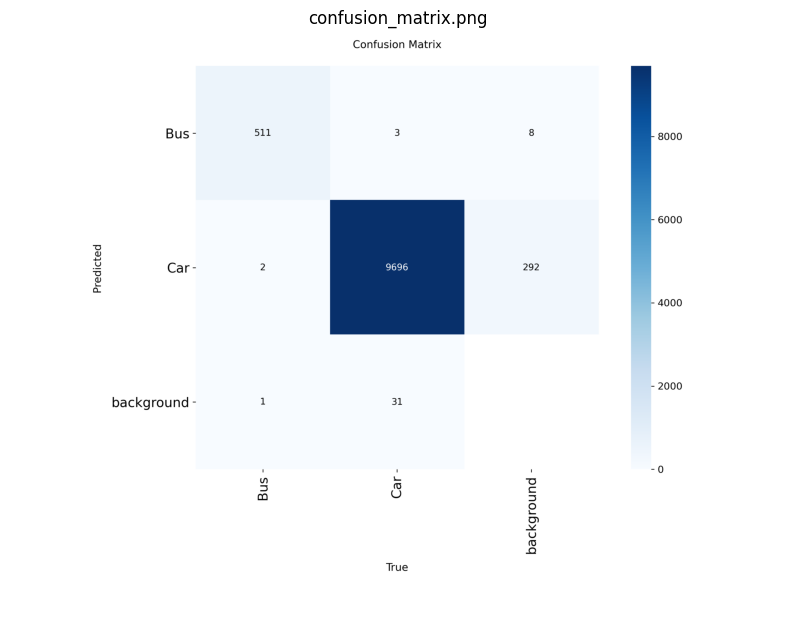

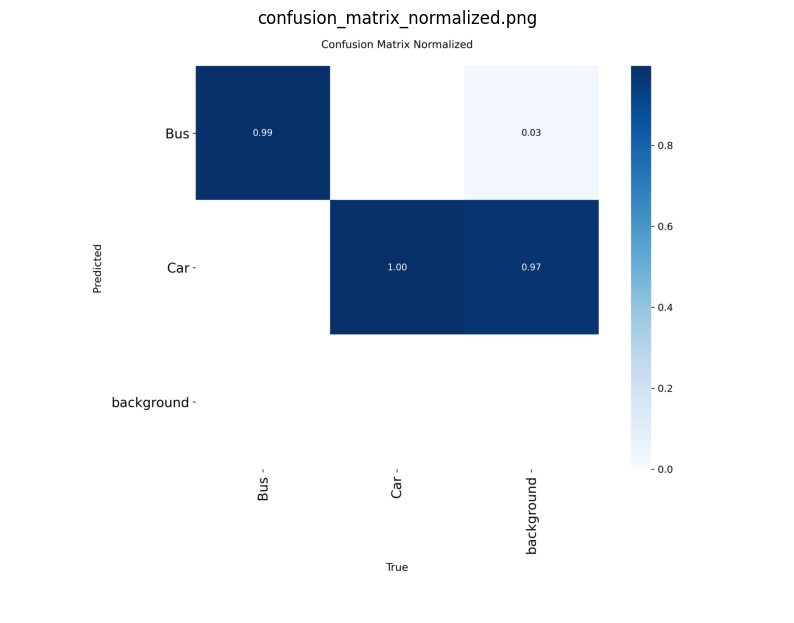

In [5]:
from ultralytics import YOLO
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

BEST_MODEL = "/content/drive/MyDrive/YOLO_Results/yolo11n_test_run/weights/best.pt"
DATA_YAML = "/content/drive/MyDrive/CrossRoad.yolov11/data.yaml"

model = YOLO(BEST_MODEL)

metrics = model.val(
    data=DATA_YAML,
    split="test",
    imgsz=640,
    plots=True
)

print("===== OVERALL METRICS =====")
print(metrics.results_dict)

save_dir = Path(metrics.save_dir)
print("\nValidation plots saved to:")
print(save_dir)

plot_files = [
    "confusion_matrix.png",
    "confusion_matrix_normalized.png",
    "PR_curve.png",
    "F1_curve.png",
    "P_curve.png",
    "R_curve.png",
]

existing_plots = [save_dir / f for f in plot_files if (save_dir / f).exists()]

print("\nFound plot files:")
for p in existing_plots:
    print("-", p.name)

for plot_path in existing_plots:
    img = Image.open(plot_path)
    plt.figure(figsize=(10, 8))
    plt.imshow(img)
    plt.title(plot_path.name)
    plt.axis("off")
    plt.show()

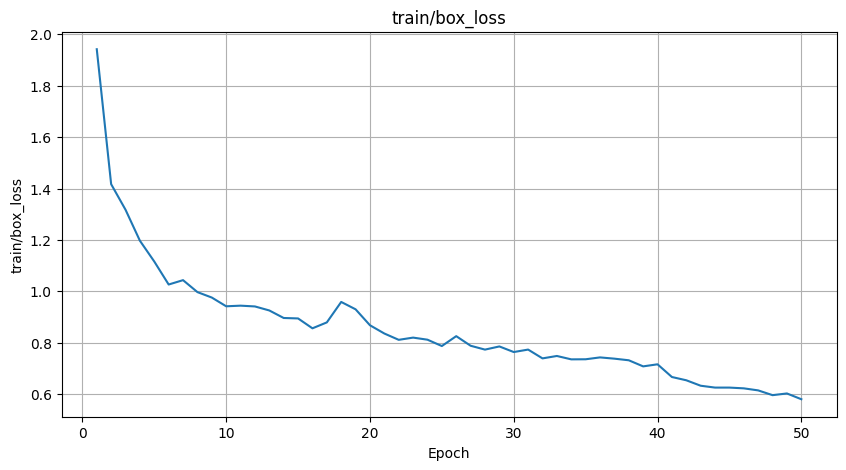

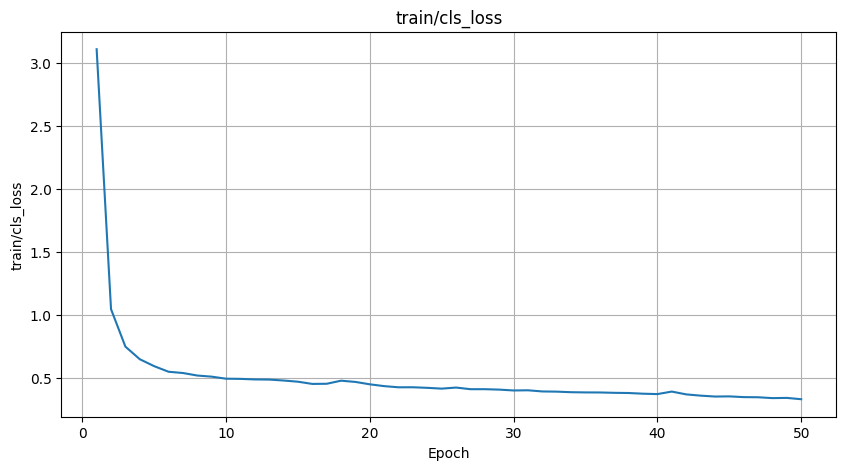

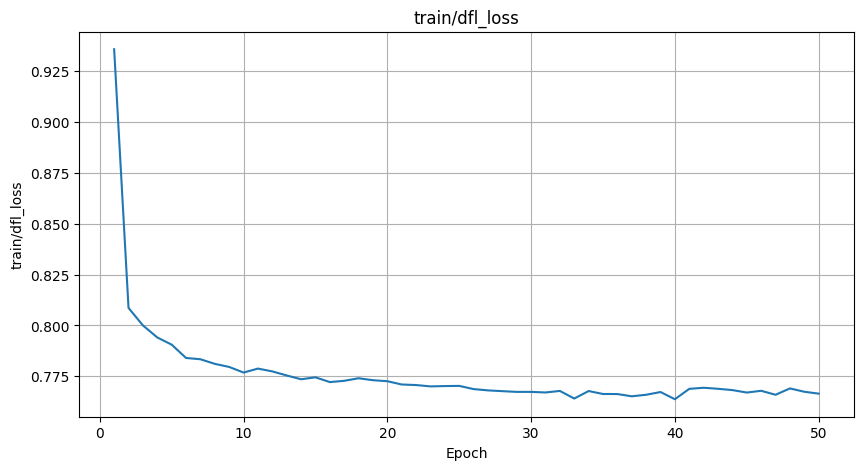

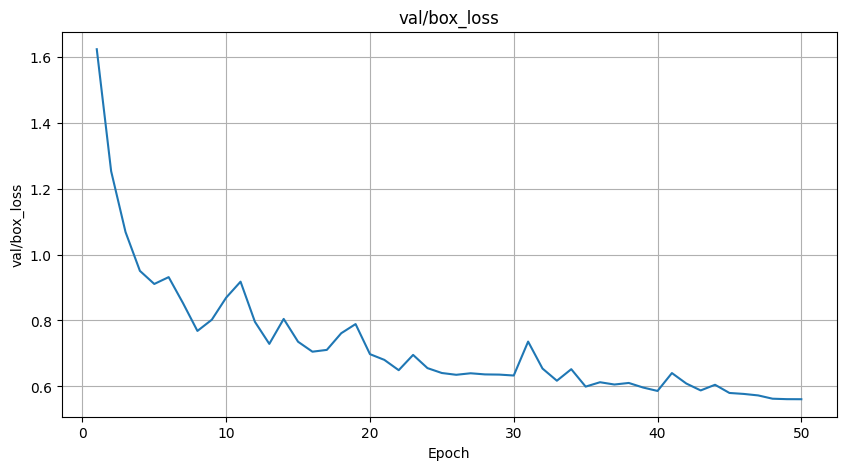

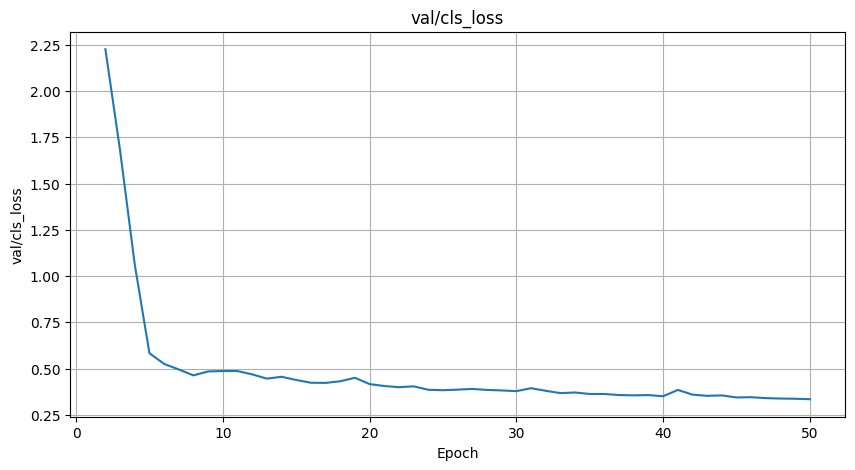

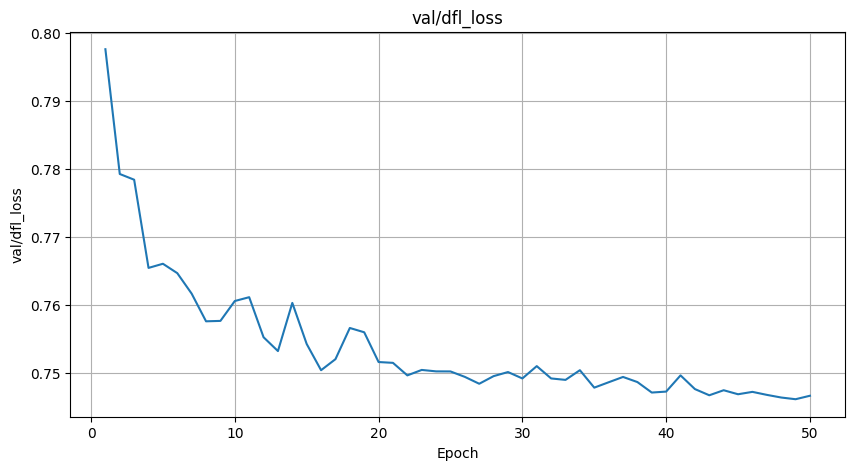

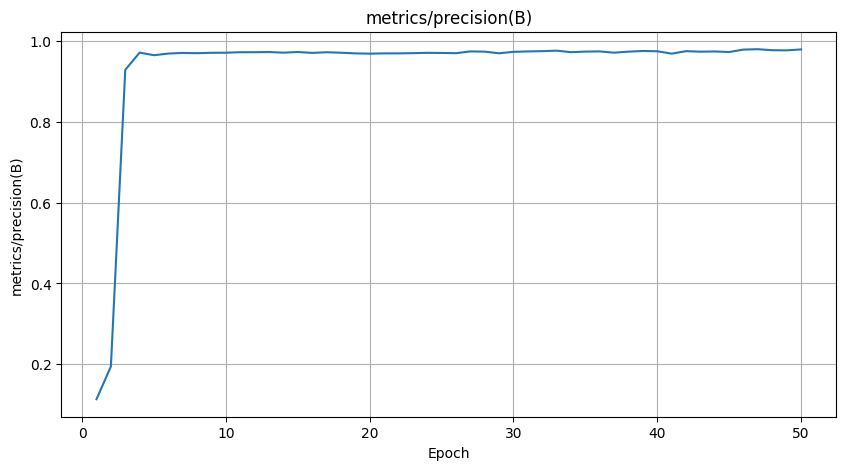

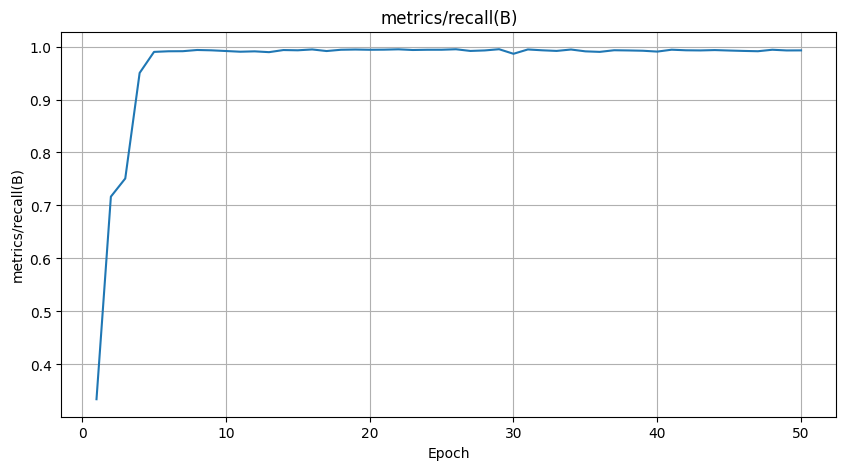

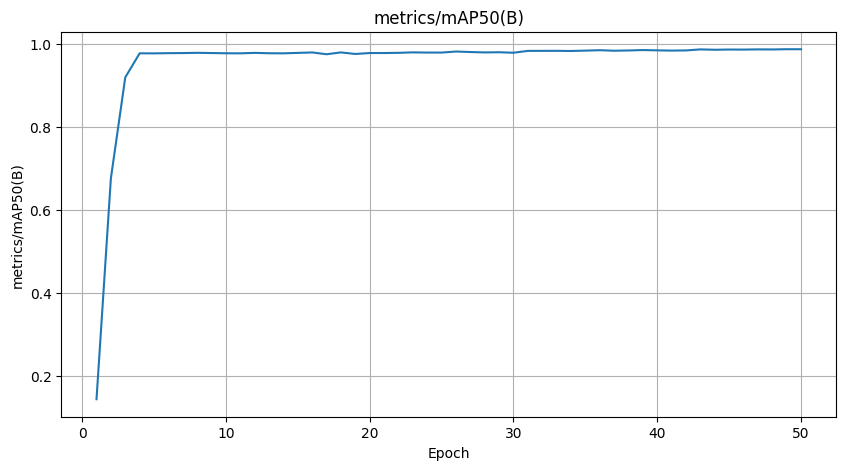

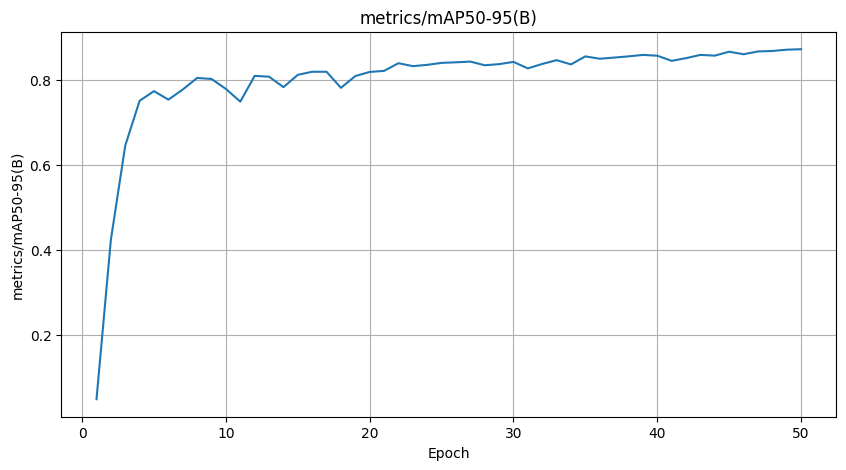

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

TRAIN_RUN_DIR = Path("/content/drive/MyDrive/YOLO_Results/yolo11n_test_run")
results_csv = TRAIN_RUN_DIR / "results.csv"

df = pd.read_csv(results_csv)
df.columns = [c.strip() for c in df.columns]

x = df["epoch"]

possible_cols = [
    "train/box_loss",
    "train/cls_loss",
    "train/dfl_loss",
    "val/box_loss",
    "val/cls_loss",
    "val/dfl_loss",
    "metrics/precision(B)",
    "metrics/recall(B)",
    "metrics/mAP50(B)",
    "metrics/mAP50-95(B)",
]

for col in possible_cols:
    if col in df.columns:
        plt.figure(figsize=(10, 5))
        plt.plot(x, df[col])
        plt.title(col)
        plt.xlabel("Epoch")
        plt.ylabel(col)
        plt.grid(True)
        plt.show()

In [8]:
from ultralytics import YOLO
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import random

MODEL_PATH = "/content/drive/MyDrive/YOLO_Results/yolo11n_test_run/weights/best.pt"
SOURCE_DIR = Path("/content/drive/MyDrive/CrossRoad.yolov11/test/images")
MODEL_RUN_DIR = Path("/content/drive/MyDrive/YOLO_Results/yolo11n_test_run")
OUTPUT_NAME = "sample_predictions"

all_images = sorted(
    list(SOURCE_DIR.glob("*.jpg")) +
    list(SOURCE_DIR.glob("*.jpeg")) +
    list(SOURCE_DIR.glob("*.png"))
)

random.seed(42)
selected_images = random.sample(all_images, min(5, len(all_images)))

print("Selected images:")
for p in selected_images:
    print(p.name)

model = YOLO(MODEL_PATH)

model.predict(
    source=[str(p) for p in selected_images],
    imgsz=640,
    conf=0.25,
    save=True,
    project=str(MODEL_RUN_DIR),
    name=OUTPUT_NAME,
    exist_ok=True,
    verbose=False
)

predict_dir = MODEL_RUN_DIR / OUTPUT_NAME

saved_images = sorted(
    list(predict_dir.glob("*.jpg")) +
    list(predict_dir.glob("*.jpeg")) +
    list(predict_dir.glob("*.png"))
)

print("\nSaved results to:")
print(predict_dir)
print("\nImages found:", len(saved_images))

for img_path in saved_images[:5]:
    img = Image.open(img_path)
    plt.figure(figsize=(12, 8))
    plt.imshow(img)
    plt.title(img_path.name)
    plt.axis("off")
    plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [1]:
!pip install sahi ultralytics

In [2]:
from pathlib import Path
from sahi import AutoDetectionModel
from sahi.predict import get_sliced_prediction
from PIL import Image
import matplotlib.pyplot as plt
import random

MODEL_PATH = "/content/drive/MyDrive/YOLO_Results/yolo11n_test_run/weights/best.pt"
SOURCE_DIR = Path("/content/drive/MyDrive/CrossRoad.yolov11/test/images")
MODEL_RUN_DIR = Path("/content/drive/MyDrive/YOLO_Results/yolo11n_test_run")
OUTPUT_DIR = MODEL_RUN_DIR / "sample_predictions_sahi"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

all_images = sorted(
    list(SOURCE_DIR.glob("*.jpg")) +
    list(SOURCE_DIR.glob("*.jpeg")) +
    list(SOURCE_DIR.glob("*.png"))
)

random.seed(42)
image_files = random.sample(all_images, min(5, len(all_images)))

print("Selected images:")
for p in image_files:
    print(p.name)

detection_model = AutoDetectionModel.from_pretrained(
    model_type="ultralytics",
    model_path=MODEL_PATH,
    confidence_threshold=0.25,
    device="cuda:0"
)

for image_path in image_files:
    result = get_sliced_prediction(
        str(image_path),
        detection_model,
        slice_height=640,
        slice_width=640,
        overlap_height_ratio=0.2,
        overlap_width_ratio=0.2
    )

    result.export_visuals(
        export_dir=str(OUTPUT_DIR),
        file_name=image_path.stem,
        hide_labels=False,
        hide_conf=False
    )

print("Done")
print("Saved to:", OUTPUT_DIR)

Selected images:
road_00792_jpg.rf.RFmEmKTZrAcdqkjRwNMK.jpg
road_00161_jpg.rf.59NwKRJ2ijq3Bv4ZZVza.jpg
road_00054_jpg.rf.vqCdwz0W7I3st8OXqiPW.jpg
road_01427_jpg.rf.jQ39LyyqIfkRZ9dVpQ2d.jpg
road_00334_jpg.rf.hwvbDdpjrqCpKDt9jdzE.jpg
Performing prediction on 8 slices.
Performing prediction on 8 slices.
Performing prediction on 8 slices.
Performing prediction on 8 slices.
Performing prediction on 8 slices.
Done
Saved to: /content/drive/MyDrive/YOLO_Results/yolo11n_test_run/sample_predictions_sahi


In [3]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

OUTPUT_DIR = Path("/content/drive/MyDrive/YOLO_Results/yolo11n_test_run/sample_predictions_sahi")

result_files = sorted(
    list(OUTPUT_DIR.glob("*.png")) +
    list(OUTPUT_DIR.glob("*.jpg")) +
    list(OUTPUT_DIR.glob("*.jpeg"))
)

print("Files found:", len(result_files))

for img_path in result_files[:5]:
    img = Image.open(img_path)
    plt.figure(figsize=(12, 8))
    plt.imshow(img)
    plt.title(img_path.name)
    plt.axis("off")
    plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [4]:
!pip install -q ultralytics sahi torchmetrics pandas
!pip install -q torchmetrics sahi ultralytics torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 36.5 MB/s eta 0:00:00


Images used for evaluation: 100


/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: Encountered more than 100 detections in a single image. This means that certain detections with the lowest scores will be ignored, that may have an undesirable impact on performance. Please consider adjusting the `max_detection_threshold` to suit your use case. To disable this warning, set attribute class `warn_on_many_detections=False`, after initializing the metric.
  warnings.warn(*args, **kwargs)


Performing prediction on 8 slices.
Performing prediction on 8 slices.
Performing prediction on 8 slices.
Performing prediction on 8 slices.
Performing prediction on 8 slices.
Performing prediction on 8 slices.
Performing prediction on 8 slices.
Performing prediction on 8 slices.
Performing prediction on 8 slices.
Performing prediction on 8 slices.
Performing prediction on 8 slices.
Performing prediction on 8 slices.
Performing prediction on 8 slices.
Performing prediction on 8 slices.
Performing prediction on 8 slices.
Performing prediction on 8 slices.
Performing prediction on 8 slices.
Performing prediction on 8 slices.
Performing prediction on 8 slices.
Performing prediction on 8 slices.
Performing prediction on 8 slices.
Performing prediction on 8 slices.
Performing prediction on 8 slices.
Performing prediction on 8 slices.
Performing prediction on 8 slices.
Performing prediction on 8 slices.
Performing prediction on 8 slices.
Performing prediction on 8 slices.
Performing predictio

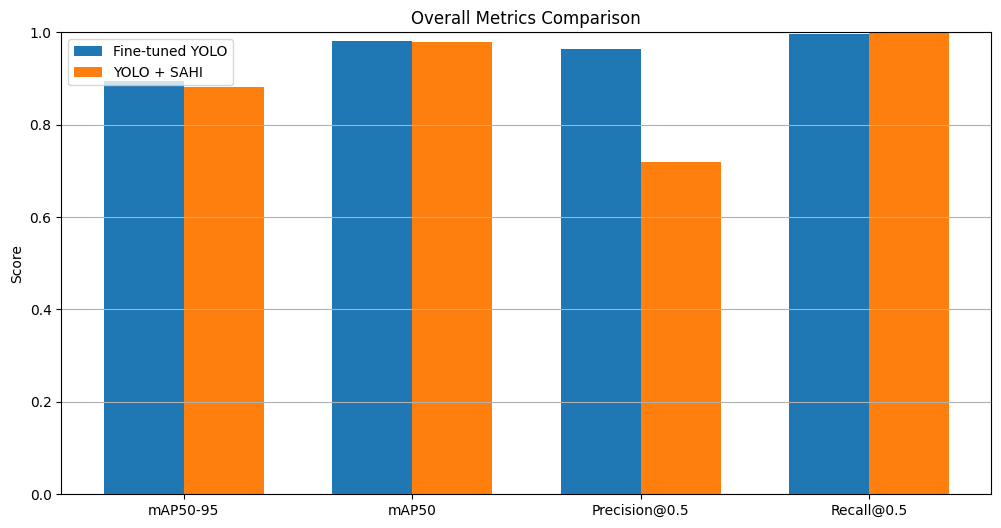

Available classes for plotting: 2


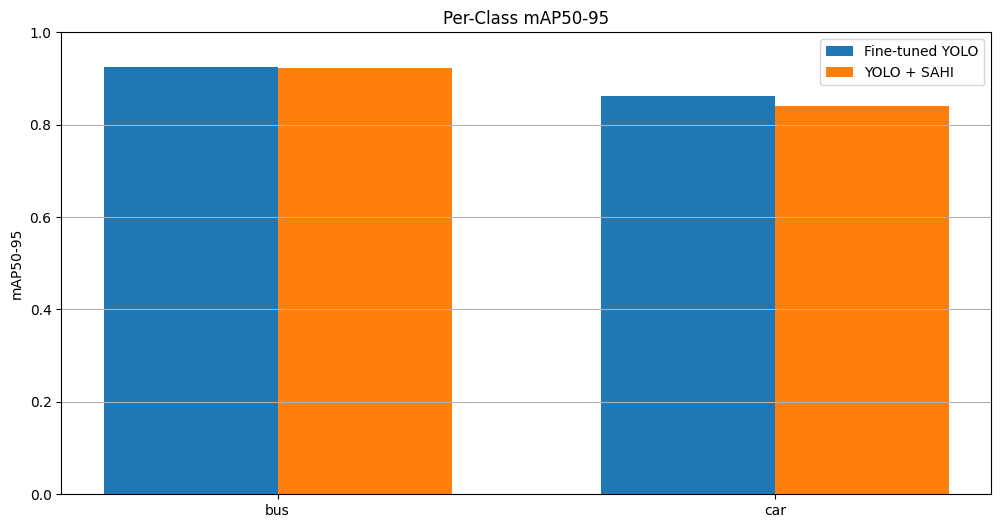

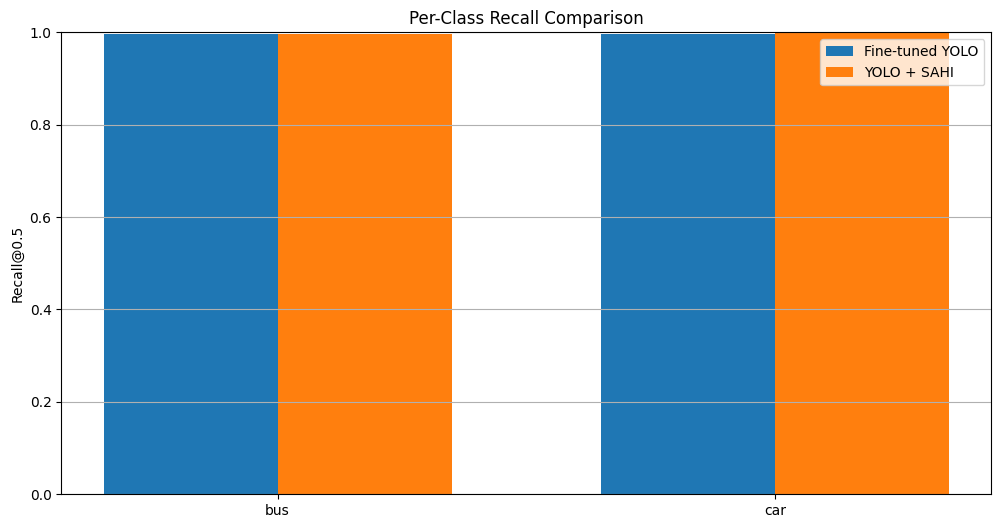

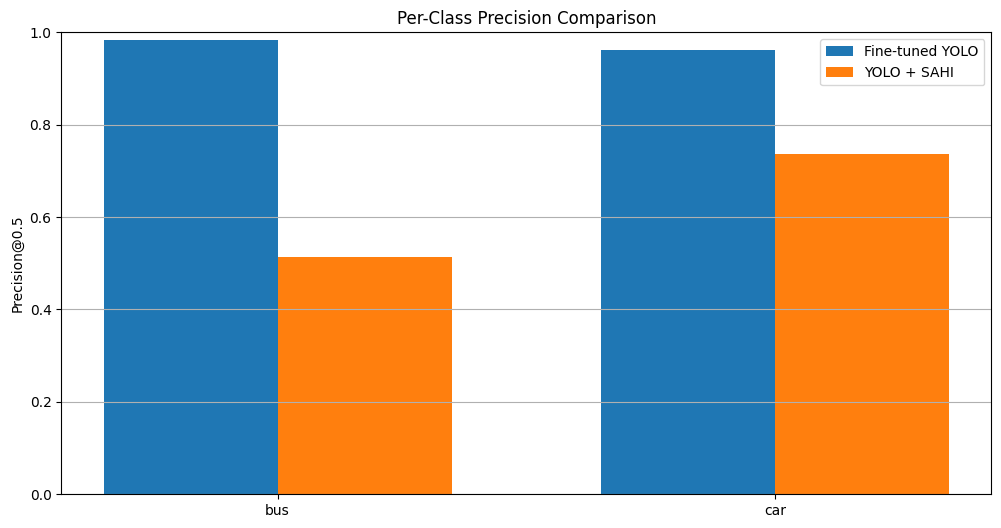

In [5]:
!pip install -q torchmetrics sahi ultralytics torchvision

from pathlib import Path
import torch
import pandas as pd
import matplotlib.pyplot as plt

from ultralytics import YOLO
from sahi import AutoDetectionModel
from sahi.predict import get_sliced_prediction
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from torchvision.ops import box_iou
from PIL import Image

# =========================
# PATHS
# =========================
MODEL_PATH = "/content/drive/MyDrive/YOLO_Results/yolo11n_test_run/weights/best.pt"
IMAGES_DIR = Path("/content/drive/MyDrive/CrossRoad.yolov11/test/images")
LABELS_DIR = Path("/content/drive/MyDrive/CrossRoad.yolov11/test/labels")

MAX_IMAGES = 100

# =========================
# CLASS MAP
# =========================
CLASS_NAMES = {
    0: "bus",
    1: "car",
    2: "truck"
}

NUM_CLASSES = len(CLASS_NAMES)

# =========================
# HELPERS
# =========================
def yolo_to_xyxy(x_center, y_center, width, height, img_w, img_h):
    x_center *= img_w
    y_center *= img_h
    width *= img_w
    height *= img_h

    x1 = x_center - width / 2
    y1 = y_center - height / 2
    x2 = x_center + width / 2
    y2 = y_center + height / 2
    return [x1, y1, x2, y2]

def load_target(label_path, img_w, img_h):
    boxes = []
    labels = []

    if not label_path.exists():
        return {
            "boxes": torch.zeros((0, 4), dtype=torch.float32),
            "labels": torch.zeros((0,), dtype=torch.int64),
        }

    with open(label_path, "r") as f:
        lines = f.readlines()

    for line in lines:
        parts = line.strip().split()
        if len(parts) != 5:
            continue

        cls_id = int(parts[0])
        x_center, y_center, width, height = map(float, parts[1:])
        box = yolo_to_xyxy(x_center, y_center, width, height, img_w, img_h)

        boxes.append(box)
        labels.append(cls_id)

    if len(boxes) == 0:
        return {
            "boxes": torch.zeros((0, 4), dtype=torch.float32),
            "labels": torch.zeros((0,), dtype=torch.int64),
        }

    return {
        "boxes": torch.tensor(boxes, dtype=torch.float32),
        "labels": torch.tensor(labels, dtype=torch.int64),
    }

def predict_finetuned(model, image_path):
    results = model.predict(
        source=str(image_path),
        imgsz=640,
        conf=0.25,
        verbose=False
    )

    r = results[0]

    if r.boxes is None or len(r.boxes) == 0:
        return {
            "boxes": torch.zeros((0, 4), dtype=torch.float32),
            "scores": torch.zeros((0,), dtype=torch.float32),
            "labels": torch.zeros((0,), dtype=torch.int64),
        }

    return {
        "boxes": r.boxes.xyxy.cpu().to(torch.float32),
        "scores": r.boxes.conf.cpu().to(torch.float32),
        "labels": r.boxes.cls.cpu().to(torch.int64),
    }

def predict_sahi(detection_model, image_path):
    result = get_sliced_prediction(
        str(image_path),
        detection_model,
        slice_height=640,
        slice_width=640,
        overlap_height_ratio=0.2,
        overlap_width_ratio=0.2
    )

    boxes = []
    scores = []
    labels = []

    for obj in result.object_prediction_list:
        bbox = obj.bbox
        score = obj.score.value
        cls_id = int(obj.category.id)

        boxes.append([bbox.minx, bbox.miny, bbox.maxx, bbox.maxy])
        scores.append(score)
        labels.append(cls_id)

    if len(boxes) == 0:
        return {
            "boxes": torch.zeros((0, 4), dtype=torch.float32),
            "scores": torch.zeros((0,), dtype=torch.float32),
            "labels": torch.zeros((0,), dtype=torch.int64),
        }

    return {
        "boxes": torch.tensor(boxes, dtype=torch.float32),
        "scores": torch.tensor(scores, dtype=torch.float32),
        "labels": torch.tensor(labels, dtype=torch.int64),
    }

def safe_item(x):
    if hasattr(x, "item"):
        return float(x.item())
    return float(x)

# =========================
# PRECISION / RECALL @ IoU=0.5
# =========================
def compute_precision_recall_iou50(pred, target, num_classes):
    tp = [0] * num_classes
    fp = [0] * num_classes
    fn = [0] * num_classes

    pred_boxes = pred["boxes"]
    pred_labels = pred["labels"]
    pred_scores = pred["scores"]

    tgt_boxes = target["boxes"]
    tgt_labels = target["labels"]

    for cls_id in range(num_classes):
        cls_pred_mask = pred_labels == cls_id
        cls_tgt_mask = tgt_labels == cls_id

        cls_pred_boxes = pred_boxes[cls_pred_mask]
        cls_pred_scores = pred_scores[cls_pred_mask]
        cls_tgt_boxes = tgt_boxes[cls_tgt_mask]

        if len(cls_pred_boxes) == 0 and len(cls_tgt_boxes) == 0:
            continue

        if len(cls_pred_boxes) == 0:
            fn[cls_id] += len(cls_tgt_boxes)
            continue

        if len(cls_tgt_boxes) == 0:
            fp[cls_id] += len(cls_pred_boxes)
            continue

        order = torch.argsort(cls_pred_scores, descending=True)
        cls_pred_boxes = cls_pred_boxes[order]

        ious = box_iou(cls_pred_boxes, cls_tgt_boxes)
        matched_tgts = set()

        for pred_idx in range(len(cls_pred_boxes)):
            tgt_idx = torch.argmax(ious[pred_idx]).item()
            best_iou = ious[pred_idx, tgt_idx].item()

            if best_iou >= 0.5 and tgt_idx not in matched_tgts:
                tp[cls_id] += 1
                matched_tgts.add(tgt_idx)
            else:
                fp[cls_id] += 1

        fn[cls_id] += len(cls_tgt_boxes) - len(matched_tgts)

    return tp, fp, fn

# =========================
# EVALUATION
# =========================
def evaluate_model(image_files, pred_loader, model_name):
    metric = MeanAveragePrecision(class_metrics=True)

    total_tp = [0] * NUM_CLASSES
    total_fp = [0] * NUM_CLASSES
    total_fn = [0] * NUM_CLASSES

    for image_path in image_files:
        img = Image.open(image_path)
        img_w, img_h = img.size

        label_path = LABELS_DIR / f"{image_path.stem}.txt"
        target = load_target(label_path, img_w, img_h)
        pred = pred_loader(image_path)

        metric.update([pred], [target])

        tp, fp, fn = compute_precision_recall_iou50(pred, target, NUM_CLASSES)
        total_tp = [a + b for a, b in zip(total_tp, tp)]
        total_fp = [a + b for a, b in zip(total_fp, fp)]
        total_fn = [a + b for a, b in zip(total_fn, fn)]

    metrics = metric.compute()

    map_per_class = [safe_item(x) for x in metrics["map_per_class"]]

    per_class_precision = []
    per_class_recall = []

    for cls_id in range(NUM_CLASSES):
        tp = total_tp[cls_id]
        fp = total_fp[cls_id]
        fn = total_fn[cls_id]

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0

        per_class_precision.append(precision)
        per_class_recall.append(recall)

    overall_precision = sum(total_tp) / (sum(total_tp) + sum(total_fp)) if (sum(total_tp) + sum(total_fp)) > 0 else 0.0
    overall_recall = sum(total_tp) / (sum(total_tp) + sum(total_fn)) if (sum(total_tp) + sum(total_fn)) > 0 else 0.0

    return {
        "model_name": model_name,
        "mAP50-95": safe_item(metrics["map"]),
        "mAP50": safe_item(metrics["map_50"]),
        "Precision@0.5": overall_precision,
        "Recall@0.5": overall_recall,
        "per_class_map50_95": map_per_class,
        "per_class_precision": per_class_precision,
        "per_class_recall": per_class_recall,
    }

# =========================
# LOAD MODELS
# =========================
finetuned_model = YOLO(MODEL_PATH)

sahi_model = AutoDetectionModel.from_pretrained(
    model_type="ultralytics",
    model_path=MODEL_PATH,
    confidence_threshold=0.25,
    device="cuda:0" if torch.cuda.is_available() else "cpu"
)

# =========================
# GET TEST IMAGES
# =========================
image_files = sorted(
    list(IMAGES_DIR.glob("*.jpg")) +
    list(IMAGES_DIR.glob("*.jpeg")) +
    list(IMAGES_DIR.glob("*.png"))
)

if MAX_IMAGES is not None:
    image_files = image_files[:MAX_IMAGES]

print("Images used for evaluation:", len(image_files))

# =========================
# RUN EVALUATION
# =========================
finetuned_result = evaluate_model(
    image_files=image_files,
    pred_loader=lambda image_path: predict_finetuned(finetuned_model, image_path),
    model_name="Fine-tuned YOLO"
)

sahi_result = evaluate_model(
    image_files=image_files,
    pred_loader=lambda image_path: predict_sahi(sahi_model, image_path),
    model_name="Fine-tuned YOLO + SAHI"
)

# =========================
# SUMMARY TABLE
# =========================
comparison = pd.DataFrame([
    {
        "Model": finetuned_result["model_name"],
        "mAP50-95": finetuned_result["mAP50-95"],
        "mAP50": finetuned_result["mAP50"],
        "Precision@0.5": finetuned_result["Precision@0.5"],
        "Recall@0.5": finetuned_result["Recall@0.5"],
    },
    {
        "Model": sahi_result["model_name"],
        "mAP50-95": sahi_result["mAP50-95"],
        "mAP50": sahi_result["mAP50"],
        "Precision@0.5": sahi_result["Precision@0.5"],
        "Recall@0.5": sahi_result["Recall@0.5"],
    },
])

print("\n===== OVERALL COMPARISON =====")
print(comparison)

# =========================
# PLOT 1: OVERALL BAR CHART
# =========================
metrics_to_plot = ["mAP50-95", "mAP50", "Precision@0.5", "Recall@0.5"]

plt.figure(figsize=(12, 6))
x = range(len(metrics_to_plot))
width = 0.35

yolo_vals = [comparison.iloc[0][m] for m in metrics_to_plot]
sahi_vals = [comparison.iloc[1][m] for m in metrics_to_plot]

plt.bar([i - width / 2 for i in x], yolo_vals, width=width, label="Fine-tuned YOLO")
plt.bar([i + width / 2 for i in x], sahi_vals, width=width, label="YOLO + SAHI")

plt.xticks(list(x), metrics_to_plot)
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Overall Metrics Comparison")
plt.legend()
plt.grid(axis="y")
plt.show()

# =========================
# SAFE PER-CLASS SETUP
# =========================
available_classes = min(
    len(finetuned_result["per_class_map50_95"]),
    len(sahi_result["per_class_map50_95"]),
    len(finetuned_result["per_class_precision"]),
    len(sahi_result["per_class_precision"]),
    len(finetuned_result["per_class_recall"]),
    len(sahi_result["per_class_recall"]),
    len(CLASS_NAMES),
)

print("Available classes for plotting:", available_classes)

class_ids = list(range(available_classes))
class_names_list = [CLASS_NAMES[i] for i in class_ids]
x = range(available_classes)
width = 0.35

# =========================
# PLOT 2: PER-CLASS mAP50-95
# =========================
plt.figure(figsize=(12, 6))
plt.bar(
    [i - width / 2 for i in x],
    finetuned_result["per_class_map50_95"][:available_classes],
    width=width,
    label="Fine-tuned YOLO"
)
plt.bar(
    [i + width / 2 for i in x],
    sahi_result["per_class_map50_95"][:available_classes],
    width=width,
    label="YOLO + SAHI"
)

plt.xticks(list(x), class_names_list)
plt.ylim(0, 1)
plt.ylabel("mAP50-95")
plt.title("Per-Class mAP50-95")
plt.legend()
plt.grid(axis="y")
plt.show()

# =========================
# PLOT 3: PER-CLASS RECALL
# =========================
plt.figure(figsize=(12, 6))
plt.bar(
    [i - width / 2 for i in x],
    finetuned_result["per_class_recall"][:available_classes],
    width=width,
    label="Fine-tuned YOLO"
)
plt.bar(
    [i + width / 2 for i in x],
    sahi_result["per_class_recall"][:available_classes],
    width=width,
    label="YOLO + SAHI"
)

plt.xticks(list(x), class_names_list)
plt.ylim(0, 1)
plt.ylabel("Recall@0.5")
plt.title("Per-Class Recall Comparison")
plt.legend()
plt.grid(axis="y")
plt.show()

# =========================
# PLOT 4: PER-CLASS PRECISION
# =========================
plt.figure(figsize=(12, 6))
plt.bar(
    [i - width / 2 for i in x],
    finetuned_result["per_class_precision"][:available_classes],
    width=width,
    label="Fine-tuned YOLO"
)
plt.bar(
    [i + width / 2 for i in x],
    sahi_result["per_class_precision"][:available_classes],
    width=width,
    label="YOLO + SAHI"
)

plt.xticks(list(x), class_names_list)
plt.ylim(0, 1)
plt.ylabel("Precision@0.5")
plt.title("Per-Class Precision Comparison")
plt.legend()
plt.grid(axis="y")
plt.show()